# Machine Learning Assignment 2 — Mobile Price Classification

**Student:** Aman Singh  
**BITS ID:** 2025AC05123  
**Problem type:** Four-class classification  
**Target:** `price_range`

This notebook explains the complete path from raw CSV files to saved model pipelines. The Streamlit application uses the same saved pipelines, so preprocessing is consistent during training and deployment.

## 1. Imports and project paths

The notebook is designed to run from the repository root. It imports the reusable training functions from `model/mobile_training.py` instead of maintaining a second, inconsistent training implementation.

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ROOT = Path.cwd()
if ROOT.name == "notebook":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from model.mobile_training import (
    CLASS_LABELS,
    FEATURES,
    TARGET,
    UNLABELLED_FILE,
    build_model_catalog,
    load_training_frame,
    train_and_save,
)

print("Project folder:", ROOT.name)

Project folder: aman_mobile_price_assignment


## 2. Load and inspect the labelled dataset

In [2]:
mobile_df = load_training_frame()
print("Shape:", mobile_df.shape)
print("Duplicate rows:", mobile_df.duplicated().sum())
print("Total missing feature values:", int(mobile_df[FEATURES].isna().sum().sum()))
display(mobile_df.head())

Shape: (2000, 21)
Duplicate rows: 0
Total missing feature values: 0


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
class_summary = (
    mobile_df[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis("price_range")
    .reset_index(name="records")
)
class_summary["label"] = class_summary["price_range"].map(CLASS_LABELS)
class_summary["percentage"] = 100 * class_summary["records"] / len(mobile_df)
display(class_summary)

,price_range,records,label,percentage
0,0,500,Budget,25.0
1,1,500,Lower Mid-Range,25.0
2,2,500,Upper Mid-Range,25.0
3,3,500,Premium,25.0


The four classes are perfectly balanced: each class contains 500 records. The 20 predictors are numeric. Median imputation is still included in every pipeline as a defensive production step, even though this copy of the dataset has no missing values.

## 3. Inspect the separate unlabelled Kaggle test file

In [4]:
unlabelled_df = pd.read_csv(UNLABELLED_FILE)
print("Unlabelled shape:", unlabelled_df.shape)
print("Contains target?", TARGET in unlabelled_df.columns)
print("Contains identifier?", "id" in unlabelled_df.columns)
display(unlabelled_df.head())

Unlabelled shape: (1000, 21)
Contains target? False
Contains identifier? True


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,3,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,5,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,3,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,8,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,6,18,749,810,1773,15,8,7,1,0,1


The separate Kaggle test file has an `id` column but no `price_range`. It can be used for predictions, but it cannot be used to calculate accuracy, AUC, precision, recall, F1, MCC, a confusion matrix, or a classification report. Therefore, the labelled 2,000-row file is split into training and held-out test partitions for assignment evaluation.

## 4. Review the five model pipelines

In [5]:
catalog = build_model_catalog()
for model_name, pipeline in catalog.items():
    print(f"\n{model_name}")
    print(pipeline)


Logistic Regression
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(C=3.0, max_iter=5000, random_state=123))])

Decision Tree
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', max_depth=10,
                                        min_samples_leaf=3,
                                        random_state=123))])

kNN
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler()),
                ('classifier',
                 KNeighborsClassifier(n_neighbors=31, weights='distance'))])

Naive Bayes
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('classifier', GaussianNB())])

Random Forest
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
    

Engineering choices:

- Logistic Regression and Gaussian Naive Bayes use median imputation plus standard scaling.
- kNN uses median imputation plus robust scaling because distance-based models are sensitive to feature scale and extreme values.
- Decision Tree and Random Forest use median imputation but no scaling because tree splits do not depend on Euclidean distance.
- Each model has its own pipeline object; fitted preprocessing state is never shared accidentally.
- The target is never passed into a preprocessing pipeline.

## 5. Create the fixed split, train models, and save artifacts

In [6]:
comparison = train_and_save()
display(comparison.round(4))

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9625,0.9986,0.9624,0.9625,0.9622,0.9502
1,Decision Tree,0.8175,0.9003,0.8214,0.8175,0.8182,0.7574
2,kNN,0.6350,0.8346,0.6510,0.6350,0.6412,0.5142
3,Naive Bayes,0.8050,0.9453,0.8128,0.8050,0.8075,0.7408
4,Random Forest,0.8825,0.9777,0.8845,0.8825,0.8826,0.8439


The training function creates one stratified 80/20 split using random state 123. It saves the exact 400 labelled test rows as root-level `test_data.csv`, trains only on the other 1,600 records, calculates all six required metrics, and saves the complete preprocessing-plus-classifier pipelines.

## 6. Inspect the best model on the untouched test data

In [7]:
test_df = pd.read_csv(ROOT / "test_data.csv")
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

best_row = comparison.sort_values(["MCC", "F1", "AUC"], ascending=False).iloc[0]
best_model_name = best_row["Model"]
file_map = {
    "Logistic Regression": "logistic_regression.joblib",
    "Decision Tree": "decision_tree.joblib",
    "kNN": "knn.joblib",
    "Naive Bayes": "naive_bayes.joblib",
    "Random Forest": "random_forest.joblib",
}
best_model = joblib.load(ROOT / "model" / "saved_models" / file_map[best_model_name])
best_prediction = best_model.predict(X_test)

print("Selected overall winner:", best_model_name)
print(classification_report(
    y_test,
    best_prediction,
    labels=[0, 1, 2, 3],
    target_names=[CLASS_LABELS[i] for i in range(4)],
    zero_division=0,
))

Selected overall winner: Logistic Regression
                 precision    recall  f1-score   support

         Budget       0.96      0.99      0.98       100
Lower Mid-Range       0.95      0.93      0.94       100
Upper Mid-Range       0.97      0.93      0.95       100
        Premium       0.97      1.00      0.99       100

       accuracy                           0.96       400
      macro avg       0.96      0.96      0.96       400
   weighted avg       0.96      0.96      0.96       400



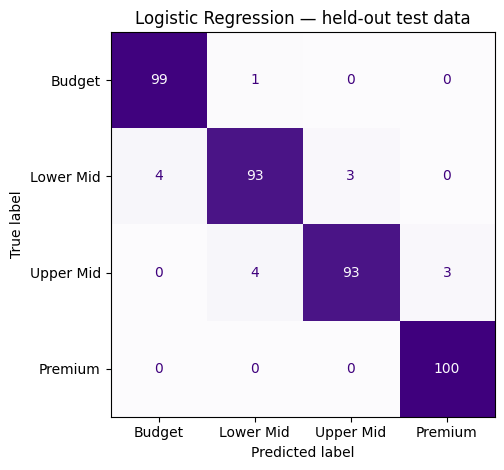

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_prediction,
    labels=[0, 1, 2, 3],
    display_labels=["Budget", "Lower Mid", "Upper Mid", "Premium"],
    cmap="Purples",
    colorbar=False,
    values_format="d",
    ax=ax,
)
ax.set_title(f"{best_model_name} — held-out test data")
plt.tight_layout()
plt.show()

## 7. Generate predictions for the unlabelled file

In [9]:
unlabelled_features = unlabelled_df[FEATURES]
unlabelled_prediction = best_model.predict(unlabelled_features)
unlabelled_probability = best_model.predict_proba(unlabelled_features)

prediction_preview = pd.DataFrame({
    "id": unlabelled_df["id"],
    "predicted_price_range": unlabelled_prediction,
    "predicted_price_label": [CLASS_LABELS[int(value)] for value in unlabelled_prediction],
})
for position, class_value in enumerate(best_model.classes_):
    prediction_preview[f"probability_class_{int(class_value)}"] = unlabelled_probability[:, position]

display(prediction_preview.head(10))

,id,predicted_price_range,predicted_price_label,probability_class_0,probability_class_1,probability_class_2,probability_class_3
0,1,3,Premium,1.870802e-14,8.635292e-06,4.212524e-01,5.787390e-01
1,2,3,Premium,3.226762e-18,6.829739e-08,1.928005e-02,9.807199e-01
2,3,2,Upper Mid-Range,1.531559e-11,5.337412e-04,6.850448e-01,3.144214e-01
3,4,3,Premium,3.109232e-27,1.671074e-14,8.364111e-06,9.999916e-01
4,5,1,Lower Mid-Range,2.045340e-03,9.489756e-01,4.897850e-02,5.679692e-07
5,6,3,Premium,2.846647e-17,1.195574e-07,2.132714e-02,9.786727e-01
6,7,3,Premium,3.381801e-30,5.464119e-16,7.203756e-07,9.999993e-01
7,8,1,Lower Mid-Range,3.001146e-03,9.854971e-01,1.150167e-02,7.777673e-08
8,9,3,Premium,1.724696e-15,1.083092e-06,5.707575e-02,9.429232e-01
9,10,0,Budget,9.990452e-01,9.548441e-04,2.983519e-10,7.533137e-22


## 8. Files used by the deployed app

- `streamlit_app.py`: interactive frontend
- `test_data.csv`: fixed labelled evaluation data
- `model/comparison.csv`: saved six-metric table
- `model/model_card.json`: feature schema, class labels, split details, and file map
- `model/saved_models/*.joblib`: five complete fitted pipelines
- `data/mobile_price_unlabelled.csv`: optional unlabelled prediction sample

To rebuild all artifacts, run `python -m model.mobile_training`. To launch the UI, run `streamlit run streamlit_app.py`.